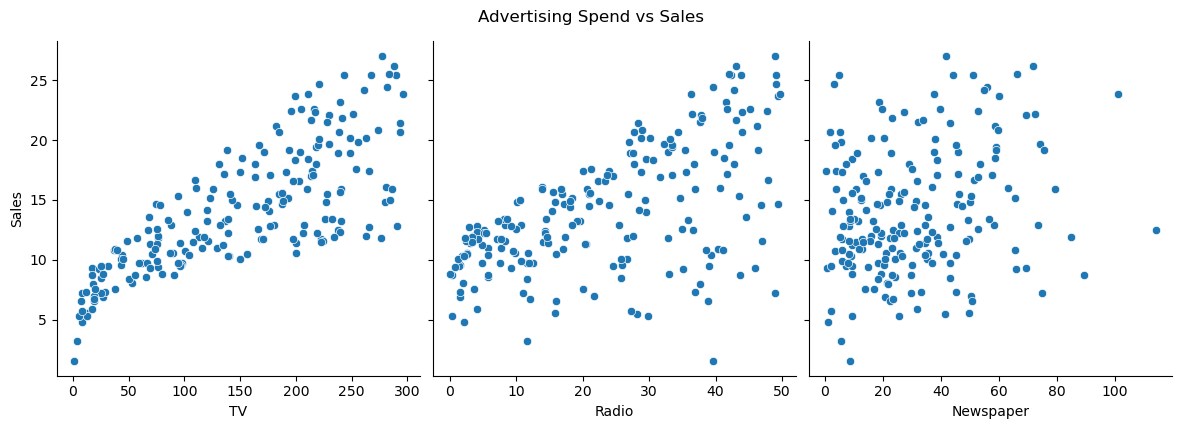

Linear Regression R2 Score: 0.899438024100912
Mean Squared Error: 3.1740973539761055

Advertising Impact on Sales:
           Coefficient (Impact on Sales)
TV                              0.044730
Radio                           0.189195
Newspaper                       0.002761

ACTIONABLE INSIGHT: Radio advertising has the highest positive correlation with sales.
Marketing budgets should prioritize Radio campaigns to maximize ROI.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Data
FILE_NAME = "Advertising.csv" # <-- Update to your downloaded file name
df = pd.read_csv(FILE_NAME)

# 2. EDA - Visualizing Advertising Impact
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=4, aspect=1, kind='scatter')
plt.suptitle("Advertising Spend vs Sales", y=1.05)
plt.show()

# 3. Prepare Data & Train Model
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# 4. Actionable Insights & Evaluation
print("Linear Regression R2 Score:", r2_score(y_test, predictions))
print("Mean Squared Error:", mean_squared_error(y_test, predictions))

coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient (Impact on Sales)'])
print("\nAdvertising Impact on Sales:")
print(coefficients)

# Identify highest impact platform for business strategy (Fixed Warning)
highest_impact = coefficients.idxmax().iloc[0]
print(f"\nACTIONABLE INSIGHT: {highest_impact} advertising has the highest positive correlation with sales.")
print(f"Marketing budgets should prioritize {highest_impact} campaigns to maximize ROI.")